In [1]:
#필요한 모듈 불러오기
#!pip install kneed
from sklearn import datasets
import pandas as pd
import numpy as np
import sklearn.metrics as metrics
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [2]:
#데이터 불러오기
df = pd.read_csv('~/Desktop/기보 전처리1.csv',encoding='cp949')
features = df.iloc[:,2:]

In [3]:
#클러스터 개수 결정 및 초기 Centroid 결정
kmeans = KMeans(init='random', n_clusters=30, n_init=30, max_iter=300, random_state=42)

#kmeans함수 실행
kmeans.fit(features)

#Labels(분류결과) 
labels = kmeans.fit_predict(features)
labels = np.where(labels==0, 30,labels)

In [4]:
#엘보우 기법을 통한 최적의 k값 추출
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter" : 300,
    "random_state": 42}

sse = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(features)
    sse.append(kmeans.inertia_)

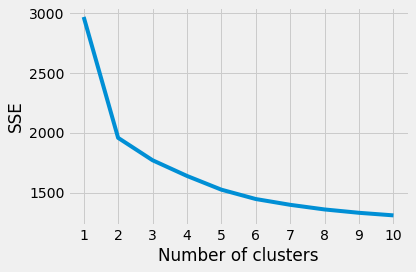

In [5]:
#엘보우 기법 그래프 추출
plt.style.use("fivethirtyeight")
plt.plot(range(1,11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of clusters")
plt.ylabel("SSE")
plt.tight_layout()
#plt.savefig('kmeans_grahp1_3.png')
plt.show()

In [6]:
#엘보우 기법을 통한 최적의 k 결과값
kl = KneeLocator(range(1,11), sse, curve="convex", direction="decreasing")
kl.elbow

3

In [7]:
#실루엣 기법을 통한 최적의 k값 추출
coefficients=[]

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(features)
    score=silhouette_score(features, kmeans.labels_)
    coefficients.append(score)

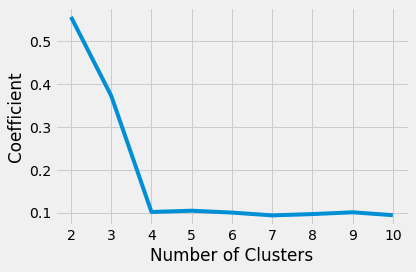

In [8]:
#실루엣 기법 그래프 추출
plt.style.use("fivethirtyeight")
plt.plot(range(2,11), coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Coefficient")
plt.show
plt.tight_layout()
#plt.savefig('kmeans_grahp2_3.png')

In [9]:
#k-means 성능평가
print('Silhouette Coefficient: %0.3f' % metrics.silhouette_score(features, labels)) #모든 샘플의 평균 실루엣 계수를 계산합니다.

Silhouette Coefficient: 0.061


In [10]:
#Label 변수 추가
df['pred'] = labels

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 287 samples in 0.001s...
[t-SNE] Computed neighbors for 287 samples in 0.012s...
[t-SNE] Computed conditional probabilities for sample 287 / 287
[t-SNE] Mean sigma: 1.104683
[t-SNE] Computed conditional probabilities in 0.006s
[t-SNE] Iteration 50: error = 63.1584282, gradient norm = 0.5603732 (50 iterations in 0.119s)


/opt/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:795: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:805: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


[t-SNE] Iteration 100: error = 63.1429367, gradient norm = 0.5263056 (50 iterations in 0.116s)
[t-SNE] Iteration 150: error = 65.2724991, gradient norm = 0.5016552 (50 iterations in 0.094s)
[t-SNE] Iteration 200: error = 63.5011177, gradient norm = 0.5279410 (50 iterations in 0.067s)
[t-SNE] Iteration 250: error = 64.6643906, gradient norm = 0.4974760 (50 iterations in 0.074s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.664391
[t-SNE] Iteration 300: error = 1.2193859, gradient norm = 0.0045407 (50 iterations in 0.058s)
[t-SNE] Iteration 350: error = 1.0387158, gradient norm = 0.0040363 (50 iterations in 0.065s)
[t-SNE] Iteration 400: error = 1.0003817, gradient norm = 0.0008485 (50 iterations in 0.047s)
[t-SNE] Iteration 450: error = 0.9740214, gradient norm = 0.0015940 (50 iterations in 0.087s)
[t-SNE] Iteration 500: error = 0.9583530, gradient norm = 0.0003008 (50 iterations in 0.045s)
[t-SNE] Iteration 550: error = 0.9517813, gradient norm = 0.0006148 (50 

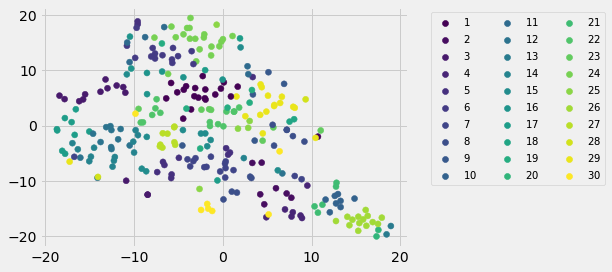

In [11]:
#차원축소 및 결과 그래프 출력
tsne = TSNE(verbose=2,random_state=42).fit_transform(features)
fig, ax = plt.subplots()
scatter=ax.scatter(tsne[:,0],tsne[:,1],c=labels)
legend1 = ax.legend(*scatter.legend_elements(num=None), bbox_to_anchor=(1.05, 1.0), ncol=3, loc='upper left', fontsize=10)
ax.add_artist(legend1)
plt.tight_layout()
#plt.savefig('kmeans_grahp.png')

In [12]:
#Label별 기술통계량 추출
#df.groupby('pred').describe().to_excel('./kmeans__그룹별 기술통계량3.xlsx')